# NLP Project 5: Social Media Comment Analysis

Problem Statement:

A company regularly launches products and marketing campaigns on social media platforms where
customers share comments, opinions, and reactions. Understanding public sentiment and customer
perception is important for brand reputation and business growth. Since social media generates huge
volumes of unstructured text data, the company wants to use NLP techniques to analyze customer
comments, identify trending topics, and understand overall public opinion about its products and
services.

Tasks
1. Collect social media comments.
2. Clean and preprocess text.
3. Perform sentiment analysis.
4. Identify trending topics.
5. Visualize public opinion.

In [7]:
!pip install nltk wordcloud textblob seaborn

Step1:Importing libraries

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from textblob import TextBlob
from collections import Counter
from wordcloud import WordCloud
import re

In [21]:
comments = [
    "I absolutely love this new product!",
    "Worst customer service ever.",
    "Amazing quality and fast delivery.",
    "The packaging was damaged.",
    "Excellent experience, highly recommend!",
    "Not worth the money.",
    "Very happy with my purchase.",
    "The app is slow and crashes often.",
    "Fantastic features and easy to use.",
    "I am disappointed with the update.",
    "Great product!",
    "Loved the design.",
    "Terrible support.",
    "Very affordable and useful.",
    "Best purchase I've made."
]

df = pd.DataFrame(comments, columns=["Comment"])

df.head()

,Comment
0,I absolutely love this new product!
1,Worst customer service ever.
2,Amazing quality and fast delivery.
3,The packaging was damaged.
4,"Excellent experience, highly recommend!"


Step 2:Text Cleaning

In [22]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    return text

df["Cleaned"] = df["Comment"].apply(clean_text)

df.head()

,Comment,Cleaned
0,I absolutely love this new product!,i absolutely love this new product
1,Worst customer service ever.,worst customer service ever
2,Amazing quality and fast delivery.,amazing quality and fast delivery
3,The packaging was damaged.,the packaging was damaged
4,"Excellent experience, highly recommend!",excellent experience highly recommend


Step 3- Sentiment Analysis

In [23]:
def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity

    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

df["Sentiment"] = df["Cleaned"].apply(get_sentiment)

df

,Comment,Cleaned,Sentiment
0,I absolutely love this new product!,i absolutely love this new product,Positive
1,Worst customer service ever.,worst customer service ever,Negative
2,Amazing quality and fast delivery.,amazing quality and fast delivery,Positive
3,The packaging was damaged.,the packaging was damaged,Neutral
4,"Excellent experience, highly recommend!",excellent experience highly recommend,Positive
5,Not worth the money.,not worth the money,Negative
6,Very happy with my purchase.,very happy with my purchase,Positive
7,The app is slow and crashes often.,the app is slow and crashes often,Negative
8,Fantastic features and easy to use.,fantastic features and easy to use,Positive
9,I am disappointed with the update.,i am disappointed with the update,Negative


Step 4: Count

In [24]:
df["Sentiment"].value_counts()

,count
Sentiment,
Positive,9
Negative,5
Neutral,1


Step 5: Visualize Sentiment

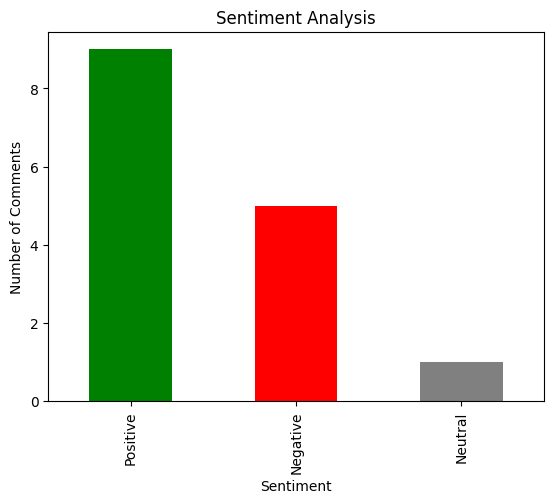

In [25]:
df["Sentiment"].value_counts().plot(
    kind="bar",
    color=["green", "red", "gray"]
)

plt.title("Sentiment Analysis")
plt.xlabel("Sentiment")
plt.ylabel("Number of Comments")
plt.show()

In [26]:
all_words = " ".join(df["Cleaned"])

words = all_words.split()

common_words = Counter(words)

common_words.most_common(10)

[('the', 5),
 ('and', 4),
 ('i', 2),
 ('product', 2),
 ('very', 2),
 ('with', 2),
 ('purchase', 2),
 ('absolutely', 1),
 ('love', 1),
 ('this', 1)]

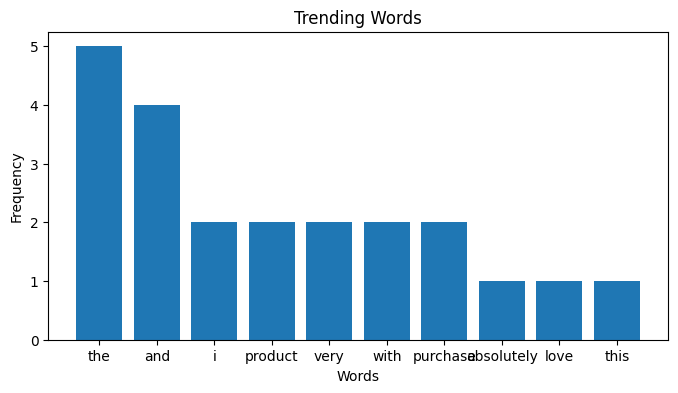

In [27]:
top_words = common_words.most_common(10)

word = [i[0] for i in top_words]
count = [i[1] for i in top_words]

plt.figure(figsize=(8,4))
plt.bar(word, count)

plt.title("Trending Words")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.show()

Step 6:wordcloud

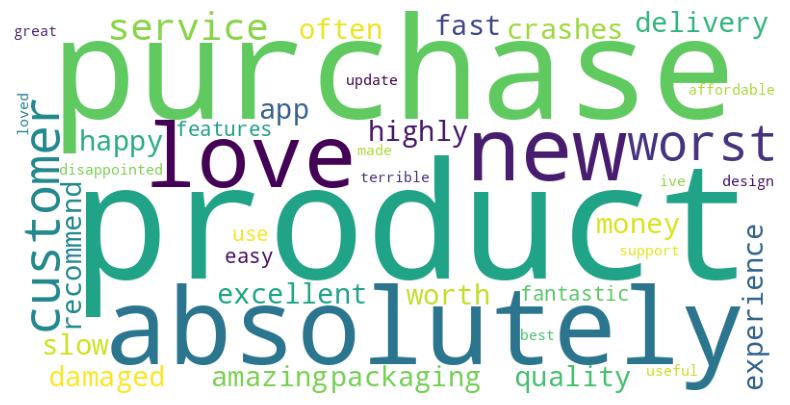

In [28]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(all_words)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

In [29]:
df

,Comment,Cleaned,Sentiment
0,I absolutely love this new product!,i absolutely love this new product,Positive
1,Worst customer service ever.,worst customer service ever,Negative
2,Amazing quality and fast delivery.,amazing quality and fast delivery,Positive
3,The packaging was damaged.,the packaging was damaged,Neutral
4,"Excellent experience, highly recommend!",excellent experience highly recommend,Positive
5,Not worth the money.,not worth the money,Negative
6,Very happy with my purchase.,very happy with my purchase,Positive
7,The app is slow and crashes often.,the app is slow and crashes often,Negative
8,Fantastic features and easy to use.,fantastic features and easy to use,Positive
9,I am disappointed with the update.,i am disappointed with the update,Negative
